# Merging data

In [1]:
from data_batching import DataBatcher
from alpaca_keys import ALPACA_API_KEY, ALPACA_SECRET_KEY

from alpaca.trading.client import TradingClient
from alpaca.trading.requests import GetAssetsRequest
from alpaca.trading.enums import AssetStatus, AssetClass

from datetime import datetime

In [10]:
client = TradingClient(ALPACA_API_KEY, ALPACA_SECRET_KEY, paper=True)

# Get all tickers
search_params = GetAssetsRequest(asset_class=AssetClass.US_EQUITY, status=AssetStatus.ACTIVE)
assets = client.get_all_assets(search_params)
all_tickers = [asset.symbol for asset in assets if asset.tradable]

# Get batched data
db = DataBatcher(all_tickers, batch_size=50, output_dir='data')

In [11]:
db.batch_tickers(time_frame='day', start_date=datetime(2023,1,1))


===== STARTED BATCHING TICKERS =====

Batch 1 / 252
 Success: 27720 rows.

Batch 2 / 252
 Success: 33512 rows.

Batch 3 / 252
 Success: 34448 rows.

Batch 4 / 252
 Success: 30058 rows.

Batch 5 / 252
 Success: 33606 rows.

Batch 6 / 252
 Success: 32815 rows.

Batch 7 / 252
 Success: 37488 rows.

Batch 8 / 252
 Success: 32267 rows.

Batch 9 / 252
 Success: 34210 rows.

Batch 10 / 252
 Success: 31857 rows.
!!! Checkpoint saved at batch 10

Batch 11 / 252
 Success: 34011 rows.

Batch 12 / 252
 Success: 34411 rows.

Batch 13 / 252
 Success: 31625 rows.

Batch 14 / 252
 Success: 34114 rows.

Batch 15 / 252
 Success: 31528 rows.

Batch 16 / 252
 Success: 34396 rows.

Batch 17 / 252
 Success: 34398 rows.

Batch 18 / 252
 Success: 30713 rows.

Batch 19 / 252
 Success: 35955 rows.

Batch 20 / 252
 Success: 27558 rows.
!!! Checkpoint saved at batch 20

Batch 21 / 252
 Success: 33640 rows.

Batch 22 / 252
 Success: 33804 rows.

Batch 23 / 252
 Success: 31816 rows.

Batch 24 / 252
 Success: 34145

In [12]:
db.merge_batched_data()


===== STARTED MERGING DATA =====
 26 files to merge!
 Merging finished, you can see the data here: data/merged_data.parquet


# Data pre-processing

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_parquet('data/merged_data.parquet')
print(data.shape)

(7765646, 9)


Let's check how much market days for each company we have

In [3]:
market_days = data.groupby('symbol')['symbol'].count().to_frame()
market_days.columns = ['count']
market_days.index.name = None
market_days['pct'] = round(market_days['count'] / market_days['count'].max(),3)
market_days.sort_values(by='count', ascending=True, inplace=True)

print(f'Min number of days: {min(market_days['count'])}')
print(f'Max number of days: {max(market_days['count'])}')

market_days

Min number of days: 1
Max number of days: 796


,count,pct
MMED,1,0.001
BUI.RTWI,1,0.001
RVI,1,0.001
AVOS,1,0.001
TDOT,1,0.001
...,...,...
ZVRA,796,1.000
ZWS,796,1.000
AA,796,1.000
ZYME,796,1.000


In [4]:
bins = np.round(np.arange(0, 1.1, 0.1),2)
labels = ['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100']

market_days['bin'] = pd.cut(market_days['pct'], bins=bins, labels=labels, include_lowest=True)
plot_data = market_days.groupby('bin')['bin'].count()
plot_data

bin
0-10       723
10-20      649
20-30      582
30-40      477
40-50      354
50-60      324
60-70      268
70-80      285
80-90      199
90-100    8426
Name: bin, dtype: int64

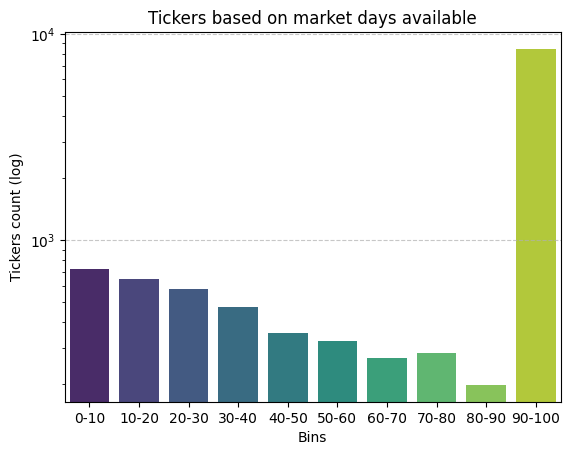

In [5]:
sns.barplot(
    x=plot_data.index, 
    y=plot_data.values, 
    hue=plot_data.index, 
    palette='viridis', 
    legend=False,
    dodge=False
)

plt.yscale('log') 
plt.title('Tickers based on market days available')
plt.xlabel('Bins')
plt.ylabel('Tickers count (log)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Leaving only the companies that were present on the market from 2023-01-01 to 2026-03-06, with high number of market days.

In [6]:
full_tickers = list(market_days[market_days['bin'] == '90-100'].index)
data = data[data['symbol'].isin(full_tickers)].reset_index(drop=True)
data

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,B,2023-01-03 05:00:00+00:00,17.54,17.95,17.450,17.83,16347356.0,56000.0,17.737309
1,B,2023-01-04 05:00:00+00:00,18.15,19.06,18.110,18.88,29095968.0,100496.0,18.755561
2,B,2023-01-05 05:00:00+00:00,18.64,18.83,18.340,18.78,17933566.0,63892.0,18.597241
3,B,2023-01-06 05:00:00+00:00,19.10,19.17,18.525,19.04,21697493.0,66739.0,19.001120
4,B,2023-01-09 05:00:00+00:00,19.22,19.37,18.960,18.97,18346736.0,60841.0,19.164238
...,...,...,...,...,...,...,...,...,...
6700154,ENR,2026-03-02 05:00:00+00:00,21.22,21.31,20.355,20.50,1278691.0,17267.0,20.575381
6700155,ENR,2026-03-03 05:00:00+00:00,19.99,20.34,19.160,19.92,1472681.0,21980.0,19.774609
6700156,ENR,2026-03-04 05:00:00+00:00,20.15,20.80,18.940,19.03,1287190.0,18406.0,19.258149
6700157,ENR,2026-03-05 05:00:00+00:00,18.77,19.27,18.510,19.20,1659271.0,20743.0,19.061203


# Analysis

In [7]:
import pandas as pd
from ga_module import GeneticPortfolio
import numpy as np

In [8]:
gp = GeneticPortfolio(data)
gp.get_data()

AttributeError: module 'ntpath' has no attribute 'exist'

In [ ]:
final_gen, final_scores = gp.run_ga_optimization(n=5)
